In [2]:
!pip install statsmodels

  Using cached statsmodels-0.14.6-cp312-cp312-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp312-cp312-win_amd64.whl (9.5 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- -


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [4]:
# LOAD DATA
df = pd.read_csv("../data/processed/matches_with_features.csv")
df.head()

,date,home_team,away_team,home_goals,away_goals,tournament,city,country,neutral,elo_home,elo_away,elo_diff
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1782.070872,1985.817755,-203.746883
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1980.544519,1787.344109,193.200410
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1782.394707,1985.493921,-203.099214
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,1970.234155,1797.654472,172.579683
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1802.249843,1965.638785,-163.388942


#### GOAL

To model the Number of Goals Scored(count data). Hence I used a Poisson regression & not a linear regression since Goals are integers (0,1,2…) where low values dominate
& matches Poisson assumptions based on exploratory analysis.

#### 1. Build Home Goals Model


In [ ]:
# Evaluate Elo difference between home & away teams
df['elo_diff'] = df['elo_home'] - df['elo_away'] 

# TRAIN POISSON MODEL
X_home = sm.add_constant(df['elo_diff'])  # Add Intercept
y_home = df['home_goals']

poisson_home = sm.GLM(y_home, X_home, family=sm.families.Poisson()).fit()

print(f"Poisson Home Goals Model Summary: {poisson_home.summary()}")

Poisson Home Goals Model Summary:                  Generalized Linear Model Regression Results                  
Dep. Variable:             home_goals   No. Observations:                49257
Model:                            GLM   Df Residuals:                    49255
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -81244.
Date:                Fri, 15 May 2026   Deviance:                       66001.
Time:                        15:46:23   Pearson chi2:                 6.46e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3042
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4

#### 2. Away Goals Model

In [6]:
X_away = sm.add_constant(-df["elo_diff"])   # Why -ve elo? If home is stronger → away is weaker hence flip perspective.
y_away = df["away_goals"]

poisson_away = sm.GLM(y_away, X_away, family=sm.families.Poisson()).fit()

print(f"Poisson Away Goals Model Summary: {poisson_away.summary()}")


Poisson Away Goals Model Summary:                  Generalized Linear Model Regression Results                  
Dep. Variable:             away_goals   No. Observations:                49257
Model:                            GLM   Df Residuals:                    49255
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -69283.
Date:                Fri, 15 May 2026   Deviance:                       63858.
Time:                        15:55:56   Pearson chi2:                 6.48e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2260
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0

## 📊 Poisson Regression Model (Goals Prediction)

We model the number of goals scored using a **Poisson regression**.

---

### 🧠 Model Formulation

The model learns:

$ \log(\lambda_{home}) = \beta_0 + \beta_1 \cdot \text{elo\_diff} $

---

### 🔍 What each term means

- $ \lambda_{home} $ → Expected number of goals scored by the home team  
- $ \beta_0 $ → Intercept (baseline scoring level)  
- $ \beta_1 $ → Effect of Elo difference  
- $ \text{elo\_diff} $ → Strength difference between teams  

---

### 🔄 Why use log?

We model the **log of expected goals** instead of goals directly because:

- Poisson requires: $ \lambda > 0 $
- Linear models can produce negative values ❌

Using log ensures:

$ \lambda_{home} = \exp(\beta_0 + \beta_1 \cdot \text{elo\_diff}) $

---

### 🎯 Key Idea

> We first compute a linear combination, then transform it using the exponential function.

---

### ⚙️ Step-by-step

1. Compute linear score:

$ z = \beta_0 + \beta_1 \cdot \text{elo\_diff} $

2. Convert to expected goals:

$ \lambda = \exp(z) $

---

### 🧠 Intuition

- If $ \text{elo\_diff} $ increases → stronger home team  
- Then $ z $ increases  
- Then $ \lambda $ increases  

👉 Stronger teams are expected to score more goals

---

### 🔥 Why this works

This is called a **log-link function**, and it is standard in Poisson regression.

It ensures:
- Predictions are always positive ✔  
- Relationship remains interpretable ✔  

---

### 🚀 Connection to Your Project

You are modeling:

$ \text{Team Strength (Elo)} \rightarrow \text{Expected Goals} $

This is the core bridge between:
- rating systems  
- probabilistic match prediction  

#### 3. Predict Expected Goals

In [7]:
# PREDICT EXPECTED GOALS
df['lambda_home'] = poisson_home.predict(X_home)
df['lambda_away'] = poisson_away.predict(X_away)

df[["lambda_home", "lambda_away"]].describe()

,lambda_home,lambda_away
count,49257.000000,49257.000000
mean,1.757050,1.182735
std,0.873803,0.605718
min,0.171919,0.115594
25%,1.205435,0.803101
50%,1.591162,1.064767
75%,2.096654,1.414211
max,13.963543,10.356095


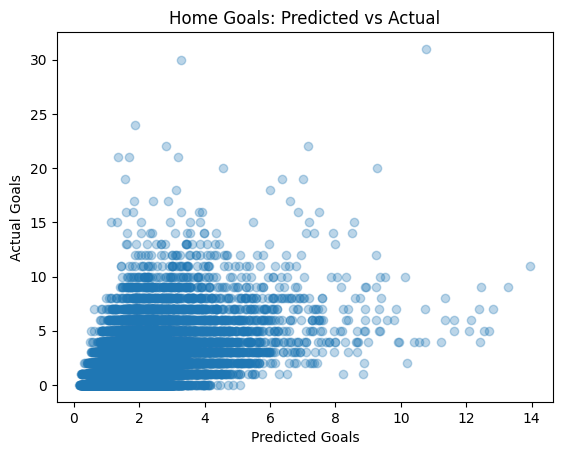

In [8]:
# Comparing Predictions vs Reality
plt.scatter(df["lambda_home"], df["home_goals"], alpha=0.3)
plt.xlabel("Predicted Goals")
plt.ylabel("Actual Goals")
plt.title("Home Goals: Predicted vs Actual")
plt.show()

In [9]:
# Global variables (will store trained parameters)
beta_home = None
beta_away = None


def train_poisson_model(data_path):
    """
    Train Poisson models and store coefficients globally.
    """

    global beta_home, beta_away

    df = pd.read_csv(data_path)

    # Feature engineering
    df['elo_diff'] = df['elo_home'] - df['elo_away']

    # --- HOME MODEL ---
    X_home = sm.add_constant(df['elo_diff'])
    y_home = df['home_goals']

    poisson_home = sm.GLM(y_home, X_home, family=sm.families.Poisson()).fit()

    # --- AWAY MODEL ---
    X_away = sm.add_constant(-df['elo_diff'])
    y_away = df['away_goals']

    poisson_away = sm.GLM(y_away, X_away, family=sm.families.Poisson()).fit()

    # Store learned parameters
    beta_home = poisson_home.params.values
    beta_away = poisson_away.params.values

    print("✅ Poisson model trained")


def get_lambda(team_a, team_b, elo_dict):
    """
    Compute expected goals for both teams using trained model.
    """

    if beta_home is None or beta_away is None:
        raise ValueError("Model not trained. Call train_poisson_model() first.")

    elo_a = elo_dict.get(team_a, 1700)
    elo_b = elo_dict.get(team_b, 1700)

    elo_diff = elo_a - elo_b

    # Home perspective
    X_home = np.array([1, elo_diff])
    lambda_home = np.exp(np.dot(beta_home, X_home))

    # Away perspective
    X_away = np.array([1, -elo_diff])
    lambda_away = np.exp(np.dot(beta_away, X_away))

    return lambda_home, lambda_away